In [16]:
#  for downloading the dataset, you can use the kagglehub library, which provides a interface to download datasets from Kaggle. Here's how you can do it:
# import kagglehub

# path = kagglehub.dataset_download(
#     "cjinny/mrnet-v1",
#     output_dir="/Users/yaseenahmed/Documents/ML Project/MRNet-v1", # use youre own path here for where you want to save the dataset guys.
#     force_download=True   # important since folder might exist partially
# )

# print("Downloaded to:", path)

In [17]:
# import os

# DATA_ROOT = "/Users/yaseenahmed/Documents/ML Project/MRNet-v1/MRNet-v1.0" 
# USe your actual path to the dataset here guys.

# print("Exists:", os.path.exists(DATA_ROOT))
# print("Contents:", os.listdir(DATA_ROOT))

In [18]:
# pip install timm scikit-learn matplotlib seaborn pandas tqdm pillow torchvision

# run the above cell to install the required libraries.

In [2]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import timm

In [20]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/mrnet_experiment")

In [5]:
# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "/Users/yaseenahmed/Documents/ML project/MRNet-v1/MRNet-v1.0"      # use your actual path to the dataset here
OOD_ROOT = "/Users/yaseenahmed/Documents/ML project/OOD_images"     # use your actual path to the OOD images here( you can create a folder and put some random images in it for testing).

# -----------------------------
# Basic settings
# -----------------------------
PLANE = "coronal"  # can be 'sagittal', 'coronal', or 'axial'
IMG_SIZE = 224
BATCH_SIZE = 2
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
NUM_WORKERS = 0
NUM_SLICES = 4       # use 3 evenly spaced slices per MRI volume
THRESHOLD = 0.45

In [8]:
# device configuration
import torch

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

BATCH_SIZE = 4
NUM_WORKERS = 0

Using device: mps


In [7]:
def load_labels(data_root, split):
    """
    Loads the three binary labels:
    1. abnormal
    2. acl
    3. meniscus

    Returns:
        dict -> {exam_id: [abnormal, acl, meniscus]}
    """
    abnormal_path = os.path.join(data_root, f"{split}-abnormal.csv")
    acl_path = os.path.join(data_root, f"{split}-acl.csv")
    meniscus_path = os.path.join(data_root, f"{split}-meniscus.csv")

    abnormal_df = pd.read_csv(abnormal_path, header=None, names=["id", "abnormal"])
    acl_df = pd.read_csv(acl_path, header=None, names=["id", "acl"])
    meniscus_df = pd.read_csv(meniscus_path, header=None, names=["id", "meniscus"])

    merged_df = abnormal_df.merge(acl_df, on="id").merge(meniscus_df, on="id")

    labels = {}
    for _, row in merged_df.iterrows():
        exam_id = f"{int(row['id']):04d}"
        labels[exam_id] = [
            float(row["abnormal"]),
            float(row["acl"]),
            float(row["meniscus"])
        ]

    return labels

In [24]:
# Training-time augmentation
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Validation / test transform
valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [25]:
class MRNetDataset(Dataset):
    def __init__(self, data_root, split="train", plane="sagittal", num_slices=5, transform=None):
        """
        A PyTorch Dataset for MRNet.

        Args:
            data_root   : root folder of MRNet
            split       : 'train' or 'valid'
            plane       : 'sagittal', 'coronal', or 'axial'
            num_slices  : number of evenly spaced slices to sample from volume
            transform   : torchvision transform to apply to each slice
        """
        self.data_root = data_root
        self.split = split
        self.plane = plane
        self.num_slices = num_slices
        self.transform = transform

        self.labels = load_labels(data_root, split)
        self.exam_ids = sorted(list(self.labels.keys()))
        self.volume_dir = os.path.join(data_root, split, plane)

    def __len__(self):
        return len(self.exam_ids)

    def normalize_slice(self, img):
        """
        Normalize a single MRI slice to range [0, 255]
        so it can be converted to a PIL image.
        """
        img = img.astype(np.float32)
        img_min = img.min()
        img_max = img.max()

        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        else:
            img = np.zeros_like(img, dtype=np.float32)

        img = (img * 255.0).clip(0, 255).astype(np.uint8)
        return img

    def get_slice_indices(self, num_total_slices):
        """
        Returns evenly spaced slice indices.
        Example: for 5 slices, picks slices spread across the full volume.
        """
        if self.num_slices >= num_total_slices:
            return np.arange(num_total_slices)

        return np.linspace(0, num_total_slices - 1, self.num_slices, dtype=int)

    def __getitem__(self, idx):
        exam_id = self.exam_ids[idx]
        volume_path = os.path.join(self.volume_dir, f"{exam_id}.npy")

        # Load MRI volume of shape (num_slices, H, W)
        volume = np.load(volume_path)

        # Select multiple evenly spaced slices
        slice_indices = self.get_slice_indices(volume.shape[0])

        slice_tensors = []
        for s_idx in slice_indices:
            img = volume[s_idx]
            img = self.normalize_slice(img)

            # Convert grayscale to RGB by duplicating channel
            pil_img = Image.fromarray(img).convert("RGB")

            if self.transform:
                pil_img = self.transform(pil_img)

            slice_tensors.append(pil_img)

        # Shape after stacking: (num_slices, 3, H, W)
        slice_tensors = torch.stack(slice_tensors, dim=0)

        # Multi-label target
        label = torch.tensor(self.labels[exam_id], dtype=torch.float32)

        return slice_tensors, label, exam_id

In [26]:
train_dataset = MRNetDataset(
    data_root=DATA_ROOT,
    split="train",
    plane=PLANE,
    num_slices=NUM_SLICES,
    transform=train_transform
)

valid_dataset = MRNetDataset(
    data_root=DATA_ROOT,
    split="valid",
    plane=PLANE,
    num_slices=NUM_SLICES,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

Train samples: 1130
Valid samples: 120


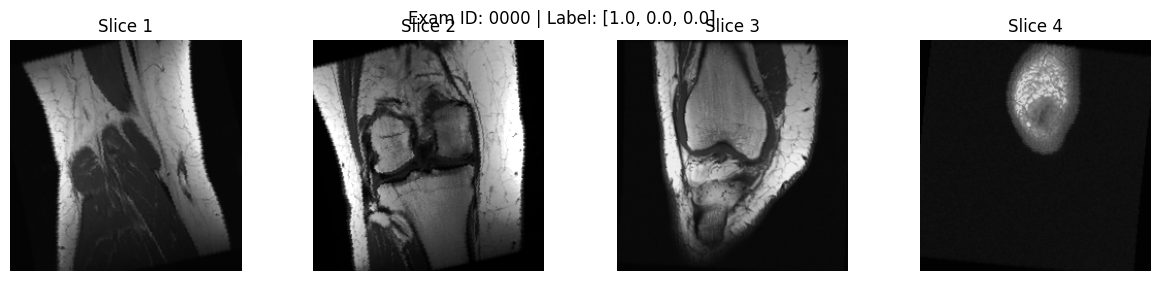

In [27]:
def denormalize_image(tensor_img):
    """
    Converts a normalized tensor image back to displayable format.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

slice_stack, label, exam_id = train_dataset[0]

plt.figure(figsize=(15, 3))
for i in range(min(NUM_SLICES, 5)):
    plt.subplot(1, min(NUM_SLICES, 5), i + 1)
    plt.imshow(denormalize_image(slice_stack[i]))
    plt.title(f"Slice {i+1}")
    plt.axis("off")

plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
plt.show()

In [28]:
def compute_pos_weights(dataset):
    """
    Computes positive class weights for BCEWithLogitsLoss.
    pos_weight = negatives / positives
    """
    all_labels = []

    for i in range(len(dataset)):
        _, label, _ = dataset[i]
        all_labels.append(label.numpy())

    all_labels = np.array(all_labels)
    positives = all_labels.sum(axis=0)
    negatives = len(all_labels) - positives

    pos_weight = negatives / (positives + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

pos_weights = compute_pos_weights(train_dataset).to(DEVICE)
print("Positive class weights:", pos_weights)

Positive class weights: tensor([0.2377, 4.4327, 1.8463], device='mps:0')


In [29]:
class ViTMultiLabel(nn.Module):
    def __init__(self, model_name="vit_small_patch16_224", num_classes=3):
        super().__init__()

        # Load pretrained ViT model from timm
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        """
        x shape: (B, S, 3, H, W)
        B = batch size
        S = number of slices per MRI

        We run ViT on each slice independently, then average slice logits.
        """
        B, S, C, H, W = x.shape

        # Merge batch and slice dimensions -> (B*S, C, H, W)
        x = x.view(B * S, C, H, W)

        # Run all slices through ViT
        logits = self.backbone(x)  # shape: (B*S, 3)

        # Restore slice dimension -> (B, S, 3)
        logits = logits.view(B, S, -1)

        # Average slice predictions over all selected slices
        logits = logits.mean(dim=1)

        return logits

In [30]:
model = ViTMultiLabel(num_classes=3).to(DEVICE)

# Freeze everything first
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze LAST transformer blocks
for block in model.backbone.blocks[-2:]:   # last 2 blocks
    for param in block.parameters():
        param.requires_grad = True

# Also keep head trainable
for param in model.backbone.head.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model)

ViTMultiLabel(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
        

In [31]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable_params)
print("Total params:", all_params)

Trainable params: 3550083
Total params: 21666819


In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, labels, _ in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)   # shape: (B, S, 3, H, W)
        labels = labels.to(device)   # shape: (B, 3)

        optimizer.zero_grad()

        outputs = model(images)      # shape: (B, 3)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    epoch_loss = total_loss / len(loader.dataset)
    return epoch_loss

In [33]:
def evaluate_model(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []
    all_ids = []

    with torch.no_grad():
        for images, labels, exam_ids in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            total_loss += loss.item() * images.size(0)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_ids.extend(exam_ids)

    avg_loss = total_loss / len(loader.dataset)

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    class_names = ["abnormal", "acl", "meniscus"]
    metrics = {}

    for i, class_name in enumerate(class_names):
        y_true = all_labels[:, i]
        y_prob = all_probs[:, i]
        y_pred = all_preds[:, i]

        metrics[class_name] = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_true, y_prob)
        }

    return avg_loss, metrics, all_labels, all_probs, all_preds, all_ids

In [34]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")
best_val_acc = 0  # NEW: track accuracy too

best_model_path = "best_vit_mrnet.pth"
last_model_path = "last_vit_mrnet.pth"

# TensorBoard (add this once above loop if not already)
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/mrnet_vit")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
        model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
    )

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # Extract overall accuracy (important for checkpointing + report)
    avg_val_acc = sum([m["accuracy"] for m in valid_metrics.values()]) / len(valid_metrics)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Avg Val Accuracy: {avg_val_acc:.4f}")

    #  TensorBoard logging
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", valid_loss, epoch)
    writer.add_scalar("Accuracy/val", avg_val_acc, epoch)

    for cls, cls_metrics in valid_metrics.items():
        print(f"\n{cls.upper()}")
        for metric_name, metric_value in cls_metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")

    #  Save LAST model (missing earlier)
    torch.save(model.state_dict(), last_model_path)

    #  Save BEST (by loss)
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"\nSaved BEST (loss) model to: {best_model_path}")

    # save best by accuracy 
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), "best_acc_model.pth")
        print("Saved BEST (accuracy) model")


Epoch 1/20


Train Loss: 0.7684
Valid Loss: 1.0345
Avg Val Accuracy: 0.6333

ABNORMAL
  accuracy: 0.7750
  precision: 0.8542
  recall: 0.8632
  f1: 0.8586
  auc_roc: 0.7600

ACL
  accuracy: 0.6000
  precision: 0.5682
  recall: 0.4630
  f1: 0.5102
  auc_roc: 0.6498

MENISCUS
  accuracy: 0.5250
  precision: 0.4762
  recall: 0.9615
  f1: 0.6369
  auc_roc: 0.5925

Saved BEST (loss) model to: best_vit_mrnet.pth
Saved BEST (accuracy) model

Epoch 2/20


Train Loss: 0.7251
Valid Loss: 1.1512
Avg Val Accuracy: 0.5861

ABNORMAL
  accuracy: 0.6583
  precision: 0.8857
  recall: 0.6526
  f1: 0.7515
  auc_roc: 0.7234

ACL
  accuracy: 0.5583
  precision: 0.5714
  recall: 0.0741
  f1: 0.1311
  auc_roc: 0.6961

MENISCUS
  accuracy: 0.5417
  precision: 0.4851
  recall: 0.9423
  f1: 0.6405
  auc_roc: 0.6298

Epoch 3/20


Train Loss: 0.7008
Valid Loss: 0.8603
Avg Val Accuracy: 0.6167

ABNORMAL
  accuracy: 0.7167
  precision: 0.8675
  recall: 0.7579
  f1: 0.8090
  auc_roc: 0.7234

ACL
  accuracy: 0.5667
  precision: 0.5104
  recall: 0.9074
  f1: 0.6533
  auc_roc: 0.7141

MENISCUS
  accuracy: 0.5667
  precision: 0.5000
  recall: 0.8077
  f1: 0.6176
  auc_roc: 0.6437

Saved BEST (loss) model to: best_vit_mrnet.pth

Epoch 4/20


Train Loss: 0.6757
Valid Loss: 0.8866
Avg Val Accuracy: 0.6472

ABNORMAL
  accuracy: 0.7333
  precision: 0.8889
  recall: 0.7579
  f1: 0.8182
  auc_roc: 0.7314

ACL
  accuracy: 0.6500
  precision: 0.5833
  recall: 0.7778
  f1: 0.6667
  auc_roc: 0.7318

MENISCUS
  accuracy: 0.5583
  precision: 0.4940
  recall: 0.7885
  f1: 0.6074
  auc_roc: 0.6640
Saved BEST (accuracy) model

Epoch 5/20


...

Train Loss: 0.5354
Valid Loss: 0.9227
Avg Val Accuracy: 0.6917

ABNORMAL
  accuracy: 0.7833
  precision: 0.8966
  recall: 0.8211
  f1: 0.8571
  auc_roc: 0.7971

ACL
  accuracy: 0.7000
  precision: 0.6552
  recall: 0.7037
  f1: 0.6786
  auc_roc: 0.7660

MENISCUS
  accuracy: 0.5917
  precision: 0.5263
  recall: 0.5769
  f1: 0.5505
  auc_roc: 0.7033

Epoch 17/20


Train Loss: 0.5397
Valid Loss: 0.9073
Avg Val Accuracy: 0.7028

ABNORMAL
  accuracy: 0.7833
  precision: 0.8966
  recall: 0.8211
  f1: 0.8571
  auc_roc: 0.7975

ACL
  accuracy: 0.7167
  precision: 0.6667
  recall: 0.7407
  f1: 0.7018
  auc_roc: 0.7654

MENISCUS
  accuracy: 0.6083
  precision: 0.5397
  recall: 0.6538
  f1: 0.5913
  auc_roc: 0.7053

Epoch 18/20


Train Loss: 0.5332
Valid Loss: 0.9129
Avg Val Accuracy: 0.7056

ABNORMAL
  accuracy: 0.7917
  precision: 0.8977
  recall: 0.8316
  f1: 0.8634
  auc_roc: 0.7975

ACL
  accuracy: 0.7083
  precision: 0.6610
  recall: 0.7222
  f1: 0.6903
  auc_roc: 0.7654

MENISCUS
  accuracy: 0.6167
  precision: 0.5500
  recall: 0.6346
  f1: 0.5893
  auc_roc: 0.7067
Saved BEST (accuracy) model

Epoch 19/20


Train Loss: 0.5327
Valid Loss: 0.9002
Avg Val Accuracy: 0.7028

ABNORMAL
  accuracy: 0.7917
  precision: 0.8977
  recall: 0.8316
  f1: 0.8634
  auc_roc: 0.7966

ACL
  accuracy: 0.7083
  precision: 0.6557
  recall: 0.7407
  f1: 0.6957
  auc_roc: 0.7654

MENISCUS
  accuracy: 0.6083
  precision: 0.5397
  recall: 0.6538
  f1: 0.5913
  auc_roc: 0.7053

Epoch 20/20


Train Loss: 0.5351
Valid Loss: 0.9022
Avg Val Accuracy: 0.7028

ABNORMAL
  accuracy: 0.7917
  precision: 0.8977
  recall: 0.8316
  f1: 0.8634
  auc_roc: 0.7971

ACL
  accuracy: 0.7083
  precision: 0.6557
  recall: 0.7407
  f1: 0.6957
  auc_roc: 0.7657

MENISCUS
  accuracy: 0.6083
  precision: 0.5397
  recall: 0.6538
  f1: 0.5913
  auc_roc: 0.7056


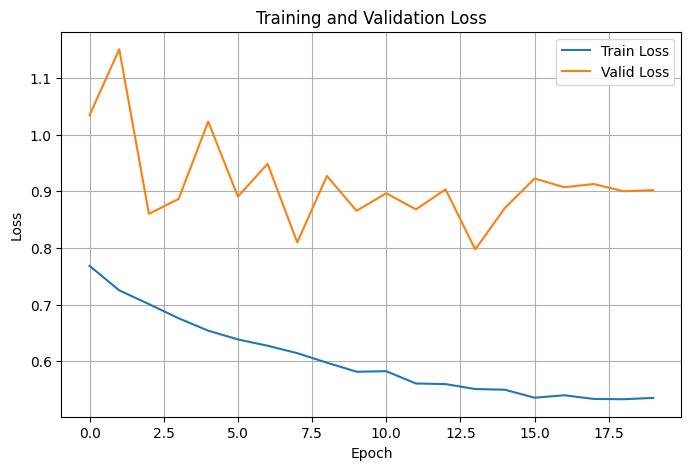

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
best_model = ViTMultiLabel(num_classes=3).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
    best_model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
)

print("Final Validation Loss:", valid_loss)

for cls, cls_metrics in valid_metrics.items():
    print(f"\n{cls.upper()}")
    for metric_name, metric_value in cls_metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

Final Validation Loss: 0.7974098046620687

ABNORMAL
accuracy: 0.7833
precision: 0.8966
recall: 0.8211
f1: 0.8571
auc_roc: 0.7954

ACL
accuracy: 0.7000
precision: 0.6286
recall: 0.8148
f1: 0.7097
auc_roc: 0.7671

MENISCUS
accuracy: 0.6083
precision: 0.5397
recall: 0.6538
f1: 0.5913
auc_roc: 0.7042


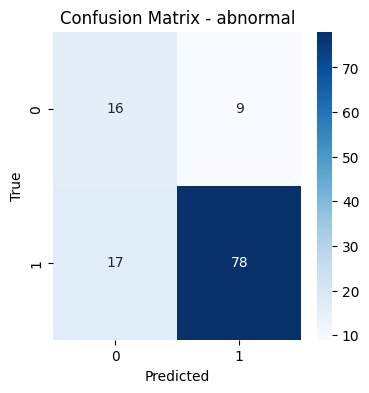

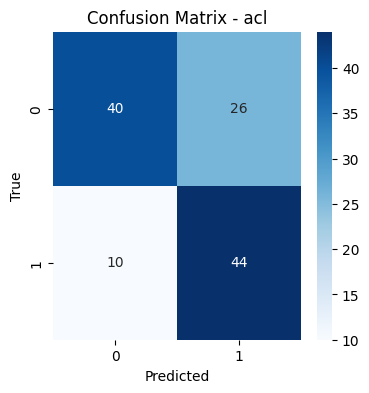

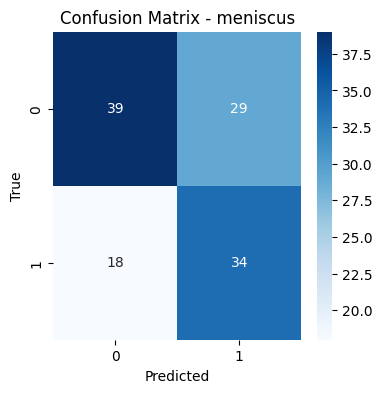

In [37]:
class_names = ["abnormal", "acl", "meniscus"]

for i, class_name in enumerate(class_names):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {class_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [38]:
results_df = pd.DataFrame({
    "exam_id": all_ids,

    "abnormal_true": all_labels[:, 0],
    "abnormal_prob": all_probs[:, 0],
    "abnormal_pred": all_preds[:, 0],

    "acl_true": all_labels[:, 1],
    "acl_prob": all_probs[:, 1],
    "acl_pred": all_preds[:, 1],

    "meniscus_true": all_labels[:, 2],
    "meniscus_prob": all_probs[:, 2],
    "meniscus_pred": all_preds[:, 2],
})

results_df.to_csv("validation_predictions.csv", index=False)
print("Saved validation_predictions.csv")

Saved validation_predictions.csv


In [39]:
def compute_attention_rollout(vit_backbone, x):
    """
    Computes attention rollout for a single input image tensor.

    Args:
        vit_backbone: timm ViT backbone
        x           : tensor of shape (1, 3, H, W)

    Returns:
        rollout mask of shape (grid_h, grid_w)
    """
    vit_backbone.eval()

    with torch.no_grad():
        # Patch embedding
        tokens = vit_backbone.patch_embed(x)  # (B, num_patches, embed_dim)

        B = tokens.shape[0]

        # Add cls token
        cls_token = vit_backbone.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_token, tokens), dim=1)

        # Add positional embeddings
        tokens = tokens + vit_backbone.pos_embed
        tokens = vit_backbone.pos_drop(tokens)

        attention_matrices = []

        # Pass tokens through each transformer block
        for block in vit_backbone.blocks:
            norm_tokens = block.norm1(tokens)

            # Manually compute attention
            B_, N, C = norm_tokens.shape
            qkv = block.attn.qkv(norm_tokens)
            qkv = qkv.reshape(B_, N, 3, block.attn.num_heads, C // block.attn.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)

            q, k, v = qkv[0], qkv[1], qkv[2]

            attn = (q @ k.transpose(-2, -1)) * block.attn.scale
            attn = attn.softmax(dim=-1)

            # Average over attention heads
            attn = attn.mean(dim=1)  # shape: (B, N, N)
            attention_matrices.append(attn)

            # Continue normal block forward
            tokens = block(tokens)

        # Attention rollout
        eye = torch.eye(attention_matrices[0].size(-1), device=x.device).unsqueeze(0)

        joint_attention = eye.repeat(B, 1, 1)
        for attn in attention_matrices:
            attn = attn + eye
            attn = attn / attn.sum(dim=-1, keepdim=True)
            joint_attention = attn @ joint_attention

        # Take cls token attention to patch tokens
        mask = joint_attention[:, 0, 1:]  # (B, num_patches)

        num_patches = mask.shape[-1]
        grid_size = int(math.sqrt(num_patches))

        mask = mask.reshape(B, grid_size, grid_size)
        return mask[0].cpu().numpy()

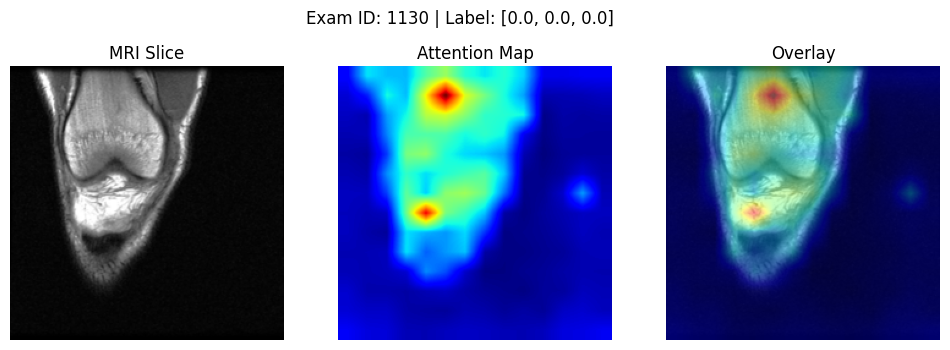

In [40]:
def show_attention_for_exam(dataset, model, exam_index=0):
    """
    Visualizes attention map for the middle selected slice of one MRI exam.
    """
    slice_stack, label, exam_id = dataset[exam_index]

    # Choose middle sampled slice for visualisation
    chosen_slice_index = len(slice_stack) // 2
    img_tensor = slice_stack[chosen_slice_index].unsqueeze(0).to(DEVICE)

    # Get rollout attention map
    attention_map = compute_attention_rollout(model.backbone, img_tensor)

    # Resize attention map to image size
    attention_map = torch.tensor(attention_map).unsqueeze(0).unsqueeze(0)
    attention_map = F.interpolate(
        attention_map,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    # Recover image for plotting
    original_img = denormalize_image(slice_stack[chosen_slice_index])

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("MRI Slice")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(attention_map, cmap="jet")
    plt.title("Attention Map")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(original_img)
    plt.imshow(attention_map, cmap="jet", alpha=0.45)
    plt.title("Overlay")
    plt.axis("off")

    plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
    plt.show()

show_attention_for_exam(valid_dataset, best_model, exam_index=0)

In [41]:
class OODImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        """
        Dataset for external knee MRI images.
        Assumes images are standard formats like jpg/png/jpeg.
        """
        self.image_paths = sorted(
            glob.glob(os.path.join(image_dir, "*.png")) +
            glob.glob(os.path.join(image_dir, "*.jpg")) +
            glob.glob(os.path.join(image_dir, "*.jpeg"))
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, os.path.basename(image_path)

In [42]:
def run_ood_inference(model, image_dir, transform, device, threshold=0.5):
    """
    Runs inference on external OOD images.
    """
    model.eval()

    ood_dataset = OODImageDataset(image_dir=image_dir, transform=transform)

    results = []
    class_names = ["abnormal", "acl", "meniscus"]

    with torch.no_grad():
        for image, filename in ood_dataset:
            # shape: (3, H, W) -> convert to fake multi-slice input of shape (1, 1, 3, H, W)
            image = image.unsqueeze(0).unsqueeze(0).to(device)

            outputs = model(image)
            probs = torch.sigmoid(outputs).squeeze(0).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            result = {"filename": filename}
            for i, class_name in enumerate(class_names):
                result[f"{class_name}_prob"] = float(probs[i])
                result[f"{class_name}_pred"] = int(preds[i])

            results.append(result)

    return pd.DataFrame(results)

In [43]:
ood_results_df = run_ood_inference(
    model=best_model,
    image_dir=OOD_ROOT,
    transform=valid_transform,
    device=DEVICE,
    threshold=THRESHOLD
)

ood_results_df

,filename,abnormal_prob,abnormal_pred,acl_prob,acl_pred,meniscus_prob,meniscus_pred
0,ACL_sag-2.png,0.841339,1,0.826017,1,0.261066,0
1,ACL_sag_1.jpg,0.673259,1,0.942021,1,0.884117,1
2,Meni_sag_2.jpg,0.964061,1,0.654735,1,0.930399,1
3,meni_coronal_1.png,0.276451,0,0.824736,1,0.583298,1
4,meni_sag_1.jpg,0.842430,1,0.144970,0,0.917752,1
5,normal_coronal.jpeg,0.155965,0,0.268449,0,0.062642,0
6,normal_sag_2.jpeg,0.409524,0,0.970641,1,0.645039,1


In [44]:
ood_results_df.to_csv("ood_predictions.csv", index=False)
print("Saved ood_predictions.csv")

Saved ood_predictions.csv


In [45]:
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
import torch

OOD_ROOT = "/Users/yaseenahmed/Documents/ML Project/OOD_images"

# stricter OOD thresholds
abnormal_threshold = 0.80
acl_threshold = 0.70
meniscus_threshold = 0.75

results = []
best_model.eval()

with torch.no_grad():
    image_paths = sorted(
        glob.glob(os.path.join(OOD_ROOT, "*.jpg")) +
        glob.glob(os.path.join(OOD_ROOT, "*.jpeg")) +
        glob.glob(os.path.join(OOD_ROOT, "*.png"))
    )

    for img_path in image_paths:
        # load as grayscale first, then normalize, then convert to RGB
        img = Image.open(img_path).convert("L")
        img = np.array(img)
        img = ((img - img.min()) / (img.max() - img.min() + 1e-8) * 255).astype(np.uint8)
        img = Image.fromarray(img).convert("RGB")

        img = valid_transform(img)

        # shape -> (1,1,3,H,W)
        img = img.unsqueeze(0).unsqueeze(0).to(DEVICE)

        output = best_model(img)
        probs = torch.sigmoid(output).cpu().numpy()[0]

        abnormal_prob, acl_prob, meniscus_prob = probs

        abnormal_pred = int(abnormal_prob >= abnormal_threshold)
        acl_pred = int(acl_prob >= acl_threshold)
        meniscus_pred = int(meniscus_prob >= meniscus_threshold)

        results.append({
            "filename": os.path.basename(img_path),
            "abnormal_prob": float(abnormal_prob),
            "abnormal_pred": abnormal_pred,
            "acl_prob": float(acl_prob),
            "acl_pred": acl_pred,
            "meniscus_prob": float(meniscus_prob),
            "meniscus_pred": meniscus_pred
        })

ood_df = pd.DataFrame(results)
ood_df

,filename,abnormal_prob,abnormal_pred,acl_prob,acl_pred,meniscus_prob,meniscus_pred
0,ACL_sag-2.png,0.844626,1,0.819287,1,0.268443,0
1,ACL_sag_1.jpg,0.850084,1,0.956280,1,0.911472,1
2,Meni_sag_2.jpg,0.966183,1,0.609192,0,0.951289,1
3,meni_coronal_1.png,0.295864,0,0.820789,1,0.587472,0
4,meni_sag_1.jpg,0.839492,1,0.142109,0,0.911734,1
5,normal_coronal.jpeg,0.216523,0,0.290268,0,0.087750,0
6,normal_sag_2.jpeg,0.411954,0,0.972791,1,0.637584,0


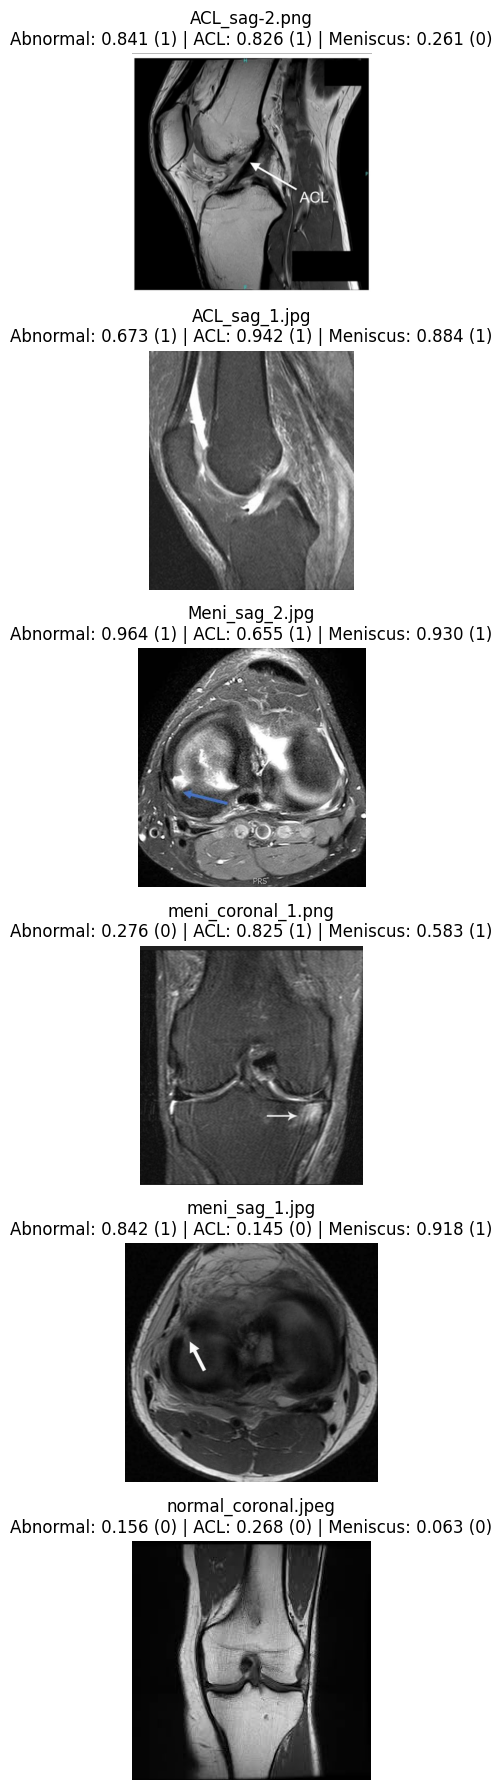

In [46]:
def show_ood_predictions(ood_root, results_df, max_images=6):
    image_files = results_df["filename"].tolist()[:max_images]

    plt.figure(figsize=(15, 3 * max_images))

    for i, filename in enumerate(image_files):
        image_path = os.path.join(ood_root, filename)
        img = Image.open(image_path).convert("RGB")

        row = results_df[results_df["filename"] == filename].iloc[0]

        title = (
            f"{filename}\n"
            f"Abnormal: {row['abnormal_prob']:.3f} ({row['abnormal_pred']}) | "
            f"ACL: {row['acl_prob']:.3f} ({row['acl_pred']}) | "
            f"Meniscus: {row['meniscus_prob']:.3f} ({row['meniscus_pred']})"
        )

        plt.subplot(max_images, 1, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ood_predictions(OOD_ROOT, ood_results_df, max_images=min(6, len(ood_results_df)))

In [47]:
# Validation metrics table
metrics_rows = []
for cls, cls_metrics in valid_metrics.items():
    row = {"class": cls}
    row.update(cls_metrics)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,class,accuracy,precision,recall,f1,auc_roc
0,abnormal,0.783333,0.896552,0.821053,0.857143,0.795368
1,acl,0.700000,0.628571,0.814815,0.709677,0.767116
2,meniscus,0.608333,0.539683,0.653846,0.591304,0.704186


In [48]:
metrics_df.to_csv("validation_metrics.csv", index=False)
print("Saved validation_metrics.csv")

Saved validation_metrics.csv


In [49]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

def show_ood_attention_maps(ood_root, model, transform, device, threshold=0.5, max_images=6):
    """
    Shows original OOD image, attention map, and overlay.
    Works with CLS-token ViT model where model.backbone is the timm ViT.
    """
    model.eval()

    image_paths = sorted(
        glob.glob(os.path.join(ood_root, "*.jpg")) +
        glob.glob(os.path.join(ood_root, "*.jpeg")) +
        glob.glob(os.path.join(ood_root, "*.png"))
    )[:max_images]

    class_names = ["abnormal", "acl", "meniscus"]

    for img_path in image_paths:
        # Load original image
        pil_img = Image.open(img_path).convert("RGB")
        original_img = np.array(pil_img)

        # Transform for model
        img_tensor = transform(pil_img).unsqueeze(0).to(device)  # (1, 3, H, W)

        # Prediction
        with torch.no_grad():
            # Make shape compatible with your volume-based model: (1,1,3,H,W)
            output = model(img_tensor.unsqueeze(1))
            probs = torch.sigmoid(output).squeeze(0).cpu().numpy()
            preds = (probs >= threshold).astype(int)

        # Attention rollout from backbone
        attention_map = compute_attention_rollout(model.backbone, img_tensor)

        # Resize attention map to image size
        attention_map = torch.tensor(attention_map).unsqueeze(0).unsqueeze(0).float()
        attention_map = F.interpolate(
            attention_map,
            size=(original_img.shape[0], original_img.shape[1]),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy()

        # Plot
        pred_text = " | ".join([
            f"{class_names[i]}: {probs[i]:.2f} ({preds[i]})" for i in range(3)
        ])

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(original_img)
        plt.title(f"Original\n{os.path.basename(img_path)}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(attention_map, cmap="jet")
        plt.title("Attention Map")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(original_img)
        plt.imshow(attention_map, cmap="jet", alpha=0.45)
        plt.title(f"Overlay\n{pred_text}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

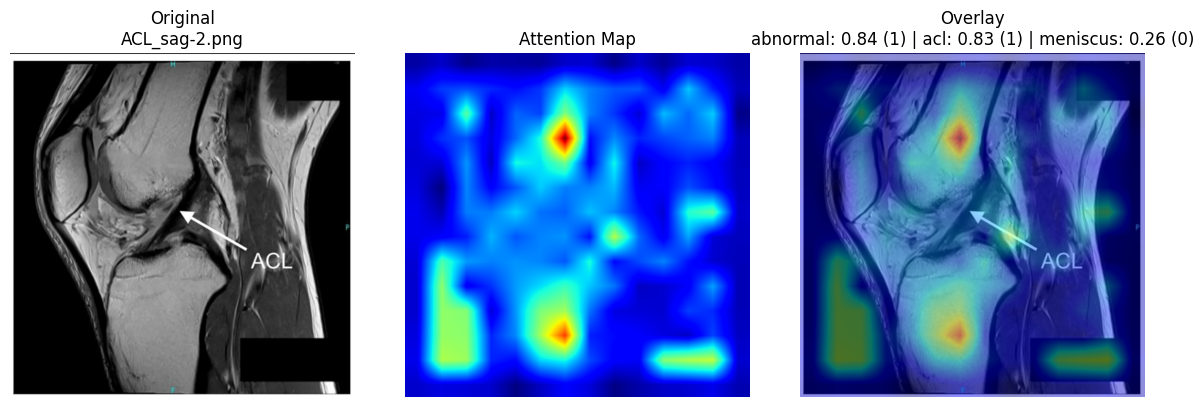

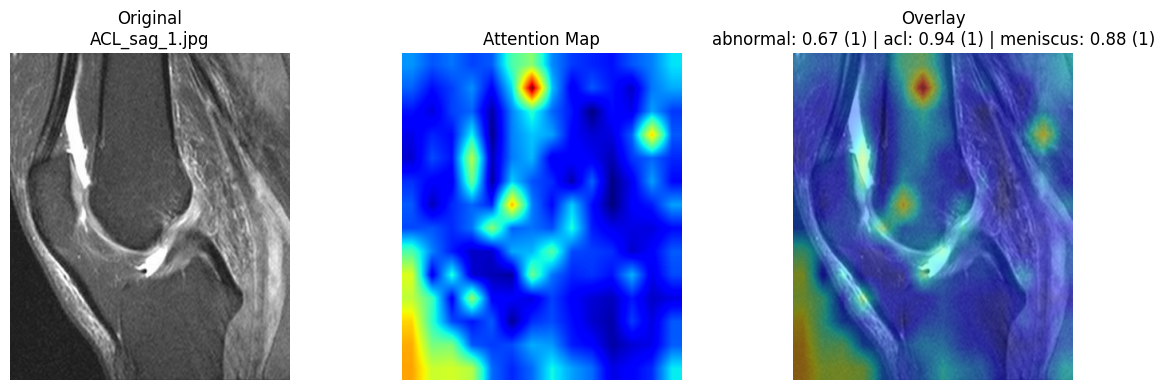

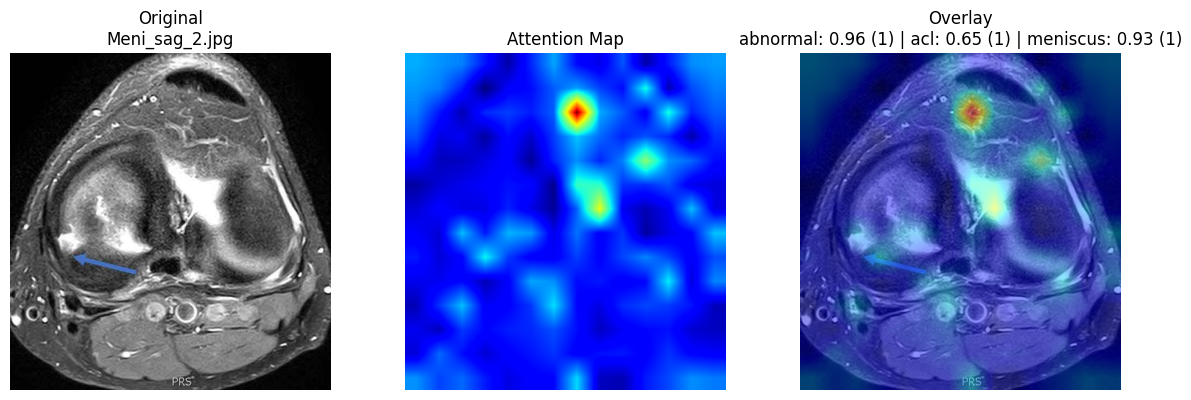

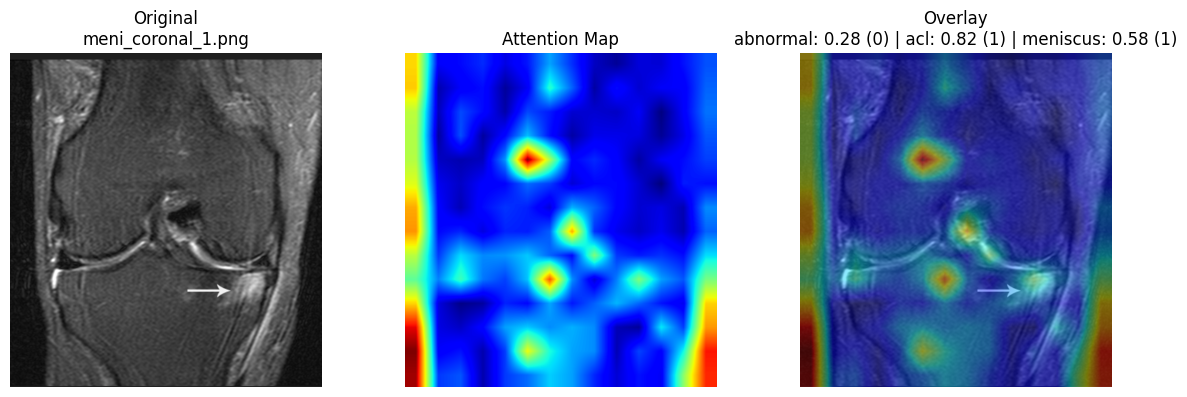

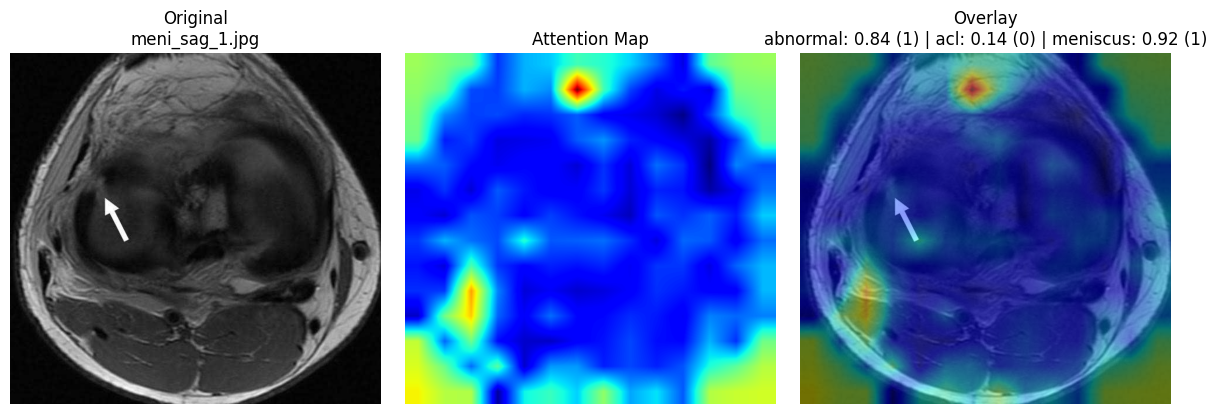

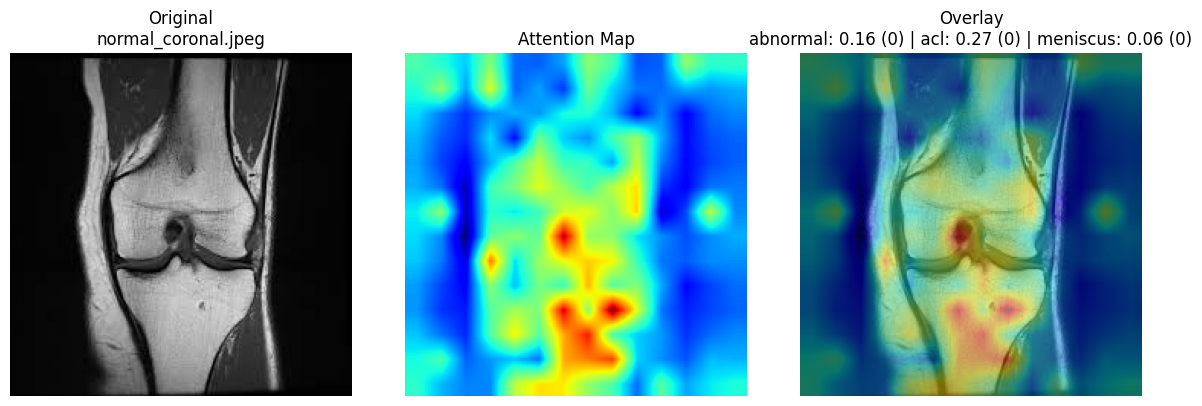

In [50]:
OOD_ROOT = "/Users/yaseenahmed/Documents/ML Project/OOD_images"

show_ood_attention_maps(
    ood_root=OOD_ROOT,
    model=best_model,
    transform=valid_transform,
    device=DEVICE,
    threshold=0.5,
    max_images=6
)